# 08 — Results Dashboard

Load all simulation results from `data/results.csv` and analyse them.

**What this notebook does:**
- Ranks all submitted alphas by fitness, Sharpe, and returns
- Visualises the Sharpe vs Turnover landscape
- Shows which themes (momentum, reversion, fundamental) work best
- Flags alphas that are ready to submit to the IQC leaderboard
- Exports a `top_alphas.csv` for record keeping

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from wq.utils import load_results, top_alphas
from wq.alpha import compute_fitness

pd.options.display.float_format = '{:.4f}'.format
pd.options.display.max_colwidth = 80

In [2]:
df = load_results()
print(f'Total simulation records: {len(df)}')
print(f'Status breakdown:')
print(df['status'].value_counts().to_string())

Total simulation records: 125
Status breakdown:
status
COMPLETE    121
ERROR         4


In [3]:
# Keep completed simulations with valid metrics
completed = df[
    df['status'].str.upper().isin(['COMPLETE', 'WARNING']) &
    df['is_sharpe'].notna() &
    df['is_fitness'].notna()
].copy()

# Recompute fitness from formula (in case API value differs)
completed['fitness_check'] = completed.apply(
    lambda r: compute_fitness(r['is_sharpe'], r['is_returns'], r['is_turnover']), axis=1
)

# Mark submittable alphas
completed['submittable'] = completed['is_sharpe'] >= 1.25

print(f'\nCompleted simulations: {len(completed)}')
print(f'Submittable (Sharpe >= 1.25): {completed["submittable"].sum()}')
print(f'\nMetric summary:')
print(completed[['is_sharpe', 'is_fitness', 'is_returns', 'is_turnover']].describe().to_string())


Completed simulations: 114
Submittable (Sharpe >= 1.25): 25

Metric summary:
       is_sharpe  is_fitness  is_returns  is_turnover
count   114.0000    114.0000    114.0000     114.0000
mean      0.3877      0.1829      0.0313       0.6861
std       1.1112      0.5030      0.0933       0.4775
min      -2.0000     -0.9000     -0.1693       0.0000
25%      -0.3250     -0.0950     -0.0252       0.2486
50%       0.7000      0.2050      0.0454       0.6773
75%       1.1000      0.6200      0.1053       1.0882
max       2.0000      1.3400      0.1929       1.5294


## Top alphas by fitness

In [4]:
top = top_alphas(completed, n=25, metric='is_fitness')
display_cols = ['expression', 'is_sharpe', 'is_fitness', 'is_returns', 'is_turnover', 'tags', 'submittable']
top[display_cols]

,expression,is_sharpe,is_fitness,is_returns,is_turnover,tags,submittable
0,"group_rank(ts_delta(assets, 4), subindustry)",1.7900,1.3400,0.1168,0.2077,"[""fundamental"", ""sweep"", ""assets""]",True
1,"group_rank(ts_delta(liabilities, 4), subindustry)",1.6900,1.2200,0.1081,0.2060,"[""fundamental"", ""sweep"", ""liabilities""]",True
2,"-1 * ts_zscore(close, 10)",1.8000,0.9000,0.1679,0.6781,"[""reversion"", ""close"", ""w10""]",True
3,"ts_mean(close, 20) - ts_mean(close, 3)",1.2000,0.8600,0.1203,0.2356,"[""reversion"", ""close"", ""w3""]",False
4,"-1 * ts_zscore(close, 5)",2.0000,0.8400,0.1693,0.9542,"[""reversion"", ""close"", ""w5""]",True
5,"group_rank(ts_delta(operating_income, 4), subindustry)",1.3300,0.8300,0.0793,0.2028,"[""fundamental"", ""sweep"", ""operating_income""]",True
6,"group_rank(liabilities, industry)",0.9900,0.8200,0.0866,0.0165,"[""fundamental"", ""sweep"", ""liabilities""]",False
7,"-1 * ts_rank(close, 5)",2.0000,0.8100,0.1607,0.9838,"[""reversion"", ""close"", ""w5""]",True
8,"group_rank(liabilities, subindustry)",0.9900,0.7800,0.0783,0.0152,"[""fundamental"", ""sweep"", ""liabilities""]",False
9,"-1 * ts_zscore(vwap, 10)",1.6100,0.7800,0.1485,0.6261,"[""reversion"", ""vwap"", ""w10""]",True


## Visualisation: Sharpe vs Turnover

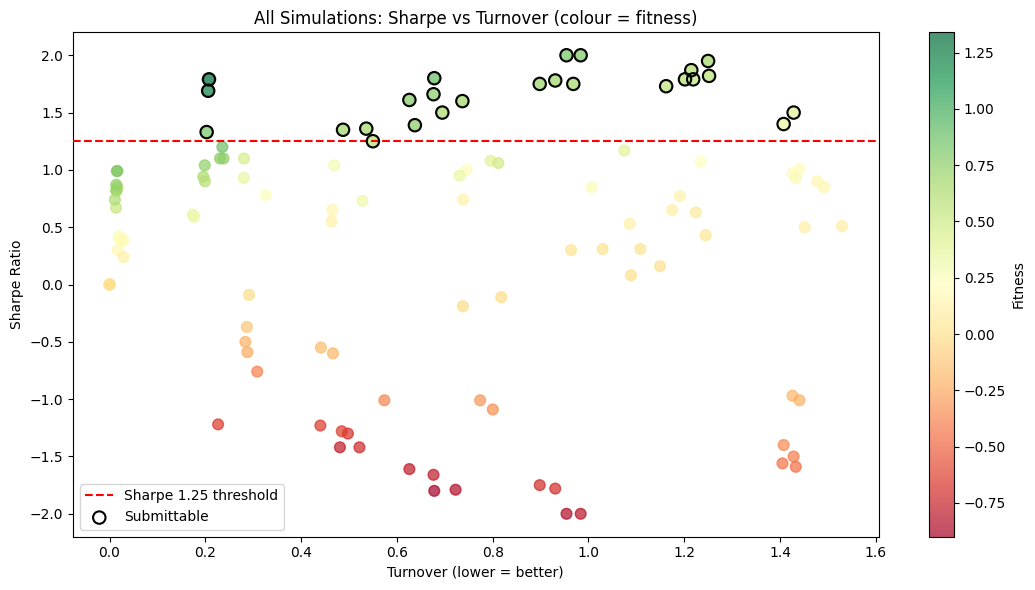

In [5]:
if len(completed) > 0:
    fig, ax = plt.subplots(figsize=(11, 6))

    # All alphas
    sc = ax.scatter(
        completed['is_turnover'],
        completed['is_sharpe'],
        c=completed['is_fitness'],
        cmap='RdYlGn',
        s=60,
        alpha=0.7,
        zorder=2,
    )
    plt.colorbar(sc, label='Fitness')

    # Threshold line
    ax.axhline(1.25, color='red', linestyle='--', lw=1.5, label='Sharpe 1.25 threshold', zorder=3)

    # Highlight submittable
    sub = completed[completed['submittable']]
    ax.scatter(sub['is_turnover'], sub['is_sharpe'],
               edgecolors='black', linewidths=1.5, facecolors='none', s=80, zorder=4, label='Submittable')

    ax.set_xlabel('Turnover (lower = better)')
    ax.set_ylabel('Sharpe Ratio')
    ax.set_title('All Simulations: Sharpe vs Turnover (colour = fitness)')
    ax.legend()
    plt.tight_layout()
    plt.show()

## Performance by theme

In [6]:
THEMES = ['momentum', 'reversion', 'fundamental', 'ml-discovered']
theme_stats = []

for theme in THEMES:
    subset = completed[completed['tags'].str.contains(theme, na=False)]
    if len(subset) == 0:
        continue
    theme_stats.append({
        'theme': theme,
        'count': len(subset),
        'mean_sharpe': subset['is_sharpe'].mean(),
        'max_sharpe': subset['is_sharpe'].max(),
        'mean_fitness': subset['is_fitness'].mean(),
        'max_fitness': subset['is_fitness'].max(),
        'pct_submittable': subset['submittable'].mean() * 100,
    })

if theme_stats:
    theme_df = pd.DataFrame(theme_stats)
    print('Performance by theme:')
    print(theme_df.to_string(index=False))
else:
    print('No tagged results yet.')

Performance by theme:
      theme  count  mean_sharpe  max_sharpe  mean_fitness  max_fitness  pct_submittable
   momentum     47      -0.4709      1.1000       -0.2256       0.4500           0.0000
  reversion     44       1.2766      2.0000        0.5243       0.9000          50.0000
fundamental     23       0.4417      1.7900        0.3648       1.3400          13.0435


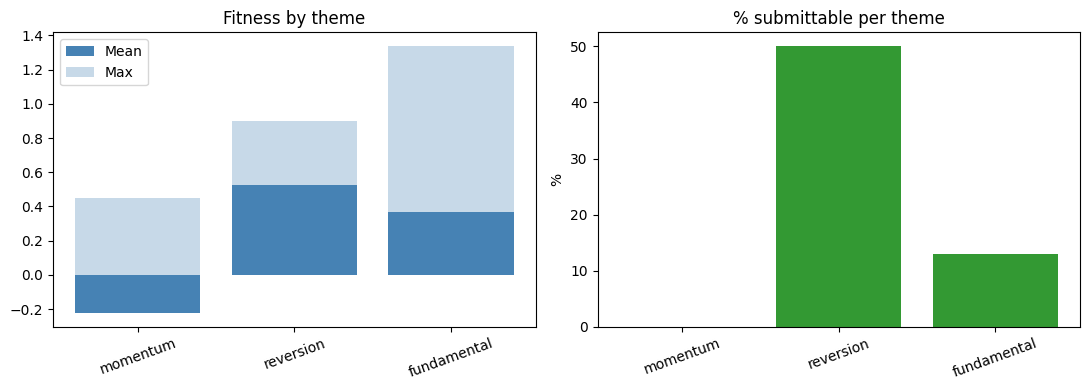

In [7]:
if theme_stats:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    themes = theme_df['theme']
    x = range(len(themes))

    axes[0].bar(x, theme_df['mean_fitness'], color='steelblue', label='Mean')
    axes[0].bar(x, theme_df['max_fitness'], color='steelblue', alpha=0.3, label='Max')
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(themes, rotation=20)
    axes[0].set_title('Fitness by theme')
    axes[0].legend()

    axes[1].bar(x, theme_df['pct_submittable'], color='green', alpha=0.8)
    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels(themes, rotation=20)
    axes[1].set_title('% submittable per theme')
    axes[1].set_ylabel('%')

    plt.tight_layout()
    plt.show()

## Fitness distribution

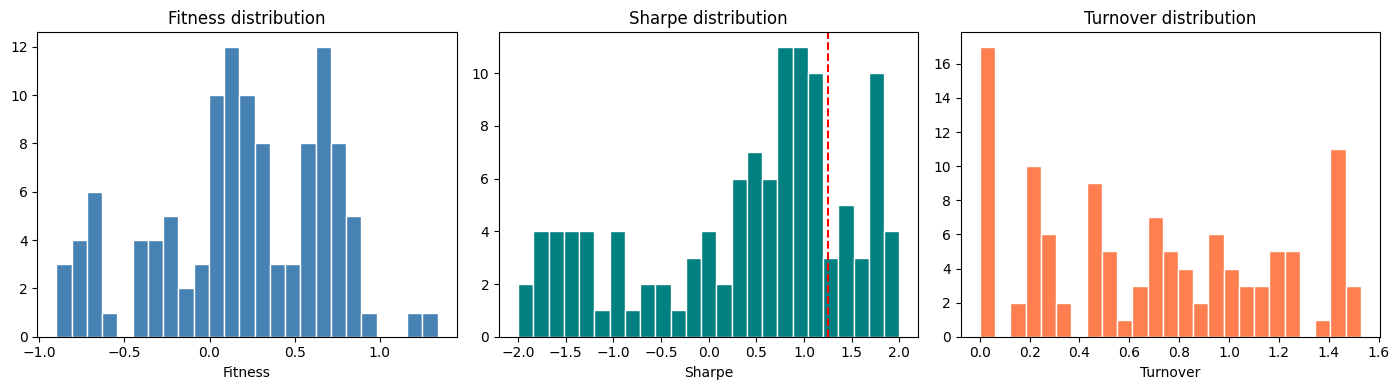

In [8]:
if len(completed) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].hist(completed['is_fitness'].dropna(), bins=25, color='steelblue', edgecolor='white')
    axes[0].set_title('Fitness distribution')
    axes[0].set_xlabel('Fitness')

    axes[1].hist(completed['is_sharpe'].dropna(), bins=25, color='teal', edgecolor='white')
    axes[1].axvline(1.25, color='red', linestyle='--', lw=1.5)
    axes[1].set_title('Sharpe distribution')
    axes[1].set_xlabel('Sharpe')

    axes[2].hist(completed['is_turnover'].dropna(), bins=25, color='coral', edgecolor='white')
    axes[2].set_title('Turnover distribution')
    axes[2].set_xlabel('Turnover')

    plt.tight_layout()
    plt.show()

## Export submittable alphas

In [9]:
submittable = completed[completed['submittable']].sort_values('is_fitness', ascending=False)
print(f'{len(submittable)} submittable alphas (Sharpe >= 1.25)')

if len(submittable) > 0:
    out_path = repo_root / 'data' / 'top_alphas.csv'
    submittable[display_cols].to_csv(out_path, index=False)
    print(f'Saved to {out_path}')
    submittable[display_cols].head(20)

25 submittable alphas (Sharpe >= 1.25)
Saved to /Users/vishal.jsoni/PersonalProjects/WorldQuant-IQC-Alpha-Research/data/top_alphas.csv


## Ideas for next steps

After reviewing results:

1. **Improve weak alphas** — take a YELLOW Sharpe alpha and tune its `decay` or `neutralization`
2. **Combine signals** — mix the best momentum and reversion alphas: `0.5 * ts_rank(close, 20) - 0.5 * ts_zscore(returns, 5)`
3. **Explore new fields** — go to notebook 01, find an unexplored fundamental field, research it in notebook 06
4. **Check correlation** — before submitting a batch to IQC, ensure alphas are not too correlated with each other